In [1]:
%pip install -q kagglehub pyarrow

In [2]:
from pathlib import Path
import os
import glob
import json
import shutil
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_DIR = Path("/content/movie_analytics_project")
RAW_DIR = PROJECT_DIR / "raw"
EXPORT_DIR = PROJECT_DIR / "powerbi_ready"
REPORT_DIR = PROJECT_DIR / "reports"

for folder in [PROJECT_DIR, RAW_DIR, EXPORT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project folder created at: {PROJECT_DIR}")

Project folder created at: /content/movie_analytics_project


In [3]:
DATASET_HANDLE = "mjshubham21/movie-dataset-for-analytics-and-visualization"
CSV_PATH = None

try:
    import kagglehub

    downloaded_path = Path(
        kagglehub.dataset_download(DATASET_HANDLE)
    )

    csv_files = list(downloaded_path.rglob("movies_dataset.csv"))

    if not csv_files:
        csv_files = list(downloaded_path.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(
            "No CSV file was found in the downloaded dataset."
        )

    CSV_PATH = csv_files[0]

    print("Dataset downloaded successfully.")
    print(f"Dataset path: {CSV_PATH}")

except Exception as error:
    print("Automatic download failed.")
    print(f"Error: {error}")
    print("Please upload the dataset manually.")

    from google.colab import files

    uploaded = files.upload()

    csv_files = [
        filename
        for filename in uploaded.keys()
        if filename.lower().endswith(".csv")
    ]

    if not csv_files:
        raise FileNotFoundError("No CSV file was uploaded.")

    CSV_PATH = Path("/content") / csv_files[0]

    print(f"Using uploaded dataset: {CSV_PATH}")

100%|██████████| 62.1M/62.1M [00:02<00:00, 25.8MB/s]

Extracting files...


Dataset downloaded successfully.
Dataset path: /root/.cache/kagglehub/datasets/mjshubham21/movie-dataset-for-analytics-and-visualization/versions/3/movies_dataset.csv


In [4]:
DATASET_HANDLE = "mjshubham21/movie-dataset-for-analytics-and-visualization"
CSV_PATH = None

try:
    import kagglehub

    downloaded_path = Path(
        kagglehub.dataset_download(DATASET_HANDLE)
    )

    csv_files = list(downloaded_path.rglob("movies_dataset.csv"))

    if not csv_files:
        csv_files = list(downloaded_path.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(
            "No CSV file was found in the downloaded dataset."
        )

    CSV_PATH = csv_files[0]

    print("Dataset downloaded successfully.")
    print(f"Dataset path: {CSV_PATH}")

except Exception as error:
    print("Automatic download failed.")
    print(f"Error: {error}")
    print("Please upload the dataset manually.")

    from google.colab import files

    uploaded = files.upload()

    csv_files = [
        filename
        for filename in uploaded.keys()
        if filename.lower().endswith(".csv")
    ]

    if not csv_files:
        raise FileNotFoundError("No CSV file was uploaded.")

    CSV_PATH = Path("/content") / csv_files[0]

    print(f"Using uploaded dataset: {CSV_PATH}")

Using Colab cache for faster access to the 'movie-dataset-for-analytics-and-visualization' dataset.
Dataset downloaded successfully.
Dataset path: /kaggle/input/movie-dataset-for-analytics-and-visualization/movies_dataset.csv


In [5]:
EXPECTED_COLUMNS = [
    "MovieID",
    "Title",
    "Genre",
    "ReleaseYear",
    "ReleaseDate",
    "Country",
    "BudgetUSD",
    "US_BoxOfficeUSD",
    "Global_BoxOfficeUSD",
    "Opening_Day_SalesUSD",
    "One_Week_SalesUSD",
    "IMDbRating",
    "RottenTomatoesScore",
    "NumVotesIMDb",
    "NumVotesRT",
    "Director",
    "LeadActor"
]

TEXT_COLUMNS = [
    "Title",
    "Genre",
    "Country",
    "Director",
    "LeadActor"
]

FINANCIAL_COLUMNS = [
    "BudgetUSD",
    "US_BoxOfficeUSD",
    "Global_BoxOfficeUSD",
    "Opening_Day_SalesUSD",
    "One_Week_SalesUSD"
]

RATING_COLUMNS = [
    "IMDbRating",
    "RottenTomatoesScore"
]

VOTE_COLUMNS = [
    "NumVotesIMDb",
    "NumVotesRT"
]

print(f"Expected number of columns: {len(EXPECTED_COLUMNS)}")

Expected number of columns: 17


In [6]:
df = pd.read_csv(
    CSV_PATH,
    low_memory=False
)

print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Number of rows: 999,999
Number of columns: 17


,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,"6,577,427.790","6,613,685.820","15,472,035.660","1,778,530.850","3,034,053.320",6.200,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,"1,883,810.100","1,930,949.150","3,637,731.120","247,115.740","831,828.840",5.200,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,"2,468,079.290","4,186,694.690","7,165,111.240","878,453.950","2,171,405.930",5.500,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,"1,447,311.460","2,023,683.920","4,373,820.260","570,657.720","898,886.010",7.300,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,"900,915.860","2,129,629.100","3,113,017.380","361,189.370","861,775.910",6.100,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [7]:
missing_columns = sorted(
    set(EXPECTED_COLUMNS) - set(df.columns)
)

extra_columns = sorted(
    set(df.columns) - set(EXPECTED_COLUMNS)
)

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

if extra_columns:
    print(f"Extra columns detected: {extra_columns}")
    print("The extra columns will be excluded.")

df = df[EXPECTED_COLUMNS].copy()

print("Dataset schema validation passed.")
print(f"Final dataset shape: {df.shape}")

display(df.head())

Dataset schema validation passed.
Final dataset shape: (999999, 17)


,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,"6,577,427.790","6,613,685.820","15,472,035.660","1,778,530.850","3,034,053.320",6.200,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,"1,883,810.100","1,930,949.150","3,637,731.120","247,115.740","831,828.840",5.200,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,"2,468,079.290","4,186,694.690","7,165,111.240","878,453.950","2,171,405.930",5.500,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,"1,447,311.460","2,023,683.920","4,373,820.260","570,657.720","898,886.010",7.300,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,"900,915.860","2,129,629.100","3,113,017.380","361,189.370","861,775.910",6.100,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [8]:
initial_audit = pd.DataFrame({
    "Column": df.columns,
    "DataType": [
        str(df[column].dtype)
        for column in df.columns
    ],
    "MissingValues": [
        int(df[column].isna().sum())
        for column in df.columns
    ],
    "MissingPercent": [
        float(df[column].isna().mean() * 100)
        for column in df.columns
    ],
    "DistinctValues": [
        int(df[column].nunique(dropna=True))
        for column in df.columns
    ],
})

display(initial_audit)

initial_audit.to_csv(
    REPORT_DIR / "01_initial_data_quality.csv",
    index=False
)

,Column,DataType,MissingValues,MissingPercent,DistinctValues
0,MovieID,int64,0,0.000,999999
1,Title,object,0,0.000,9665
2,Genre,object,0,0.000,8
3,ReleaseYear,int64,0,0.000,76
4,ReleaseDate,object,0,0.000,27757
5,Country,object,0,0.000,10
6,BudgetUSD,float64,0,0.000,988182
7,US_BoxOfficeUSD,float64,0,0.000,999610
8,Global_BoxOfficeUSD,float64,0,0.000,998527
9,Opening_Day_SalesUSD,float64,0,0.000,997984


In [9]:
NULL_STRINGS = {
    "",
    "nan",
    "none",
    "null",
    "n/a",
    "na",
}

for column in TEXT_COLUMNS:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    null_mask = df[column].str.lower().isin(NULL_STRINGS)
    df.loc[null_mask, column] = pd.NA

display(df[TEXT_COLUMNS].head())

,Title,Genre,Country,Director,LeadActor
0,Might toward capital,Comedy,China,Kristina Moore,Brian Mccormick
1,He however experience,Comedy,USA,Benjamin Hudson,Ashley Pena
2,Star responsibility politics,Comedy,USA,Kayla Young,Alexander Haley
3,Exactly live,Comedy,USA,Michael Ross,Patrick Barnett
4,Focus improve especially,Documentary,India,Faith Franklin,Duane Fletcher DDS


In [10]:
df["ReleaseDate"] = pd.to_datetime(
    df["ReleaseDate"],
    errors="coerce"
)

numeric_columns = [
    "MovieID",
    "ReleaseYear",
    *FINANCIAL_COLUMNS,
    *RATING_COLUMNS,
    *VOTE_COLUMNS,
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df.dtypes)

MovieID                          int64
Title                   string[python]
Genre                   string[python]
ReleaseYear                      int64
ReleaseDate             datetime64[ns]
Country                 string[python]
BudgetUSD                      float64
US_BoxOfficeUSD                float64
Global_BoxOfficeUSD            float64
Opening_Day_SalesUSD           float64
One_Week_SalesUSD              float64
IMDbRating                     float64
RottenTomatoesScore              int64
NumVotesIMDb                     int64
NumVotesRT                       int64
Director                string[python]
LeadActor               string[python]
dtype: object


In [11]:
rows_before = len(df)

duplicate_movie_ids = int(
    df.duplicated(subset=["MovieID"]).sum()
)

df = df.drop_duplicates(
    subset=["MovieID"],
    keep="first"
).copy()

for column in FINANCIAL_COLUMNS:
    df.loc[df[column] < 0, column] = np.nan

for column in VOTE_COLUMNS:
    df.loc[df[column] < 0, column] = np.nan

df.loc[
    ~df["IMDbRating"].between(0, 10),
    "IMDbRating"
] = np.nan

df.loc[
    ~df["RottenTomatoesScore"].between(0, 100),
    "RottenTomatoesScore"
] = np.nan

date_year = df["ReleaseDate"].dt.year

df["ReleaseYear"] = date_year.fillna(
    df["ReleaseYear"]
)

df = df.dropna(
    subset=[
        "MovieID",
        "Title",
        "Genre",
        "Country",
        "ReleaseDate",
    ]
).copy()

rows_after = len(df)

print(
    f"Duplicate MovieIDs removed: "
    f"{duplicate_movie_ids:,}"
)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(
    f"Rows removed: "
    f"{rows_before - rows_after:,}"
)

Duplicate MovieIDs removed: 0
Rows before cleaning: 999,999
Rows after cleaning:  999,999
Rows removed: 0


In [12]:
df["MovieID"] = pd.to_numeric(
    df["MovieID"],
    downcast="integer"
)

df["ReleaseYear"] = pd.to_numeric(
    df["ReleaseYear"],
    downcast="integer"
)

# Keep monetary values as float64 for accurate totals.
for column in FINANCIAL_COLUMNS:
    df[column] = df[column].astype("float64")

for column in RATING_COLUMNS:
    df[column] = pd.to_numeric(
        df[column],
        downcast="float"
    )

for column in VOTE_COLUMNS:
    df[column] = pd.to_numeric(
        df[column],
        downcast="integer"
    )

df["Genre"] = df["Genre"].astype("category")
df["Country"] = df["Country"].astype("category")

memory_mb = (
    df.memory_usage(deep=True).sum()
    / (1024 ** 2)
)

print(
    f"Optimized DataFrame memory: "
    f"{memory_mb:,.2f} MB"
)

Optimized DataFrame memory: 249.30 MB


In [14]:
df["ReleaseMonthNo"] = (
    df["ReleaseDate"]
    .dt.month
    .astype("int8")
)

df["ReleaseMonth"] = (
    df["ReleaseDate"]
    .dt.month_name()
    .astype("category")
)

df["ReleaseQuarter"] = (
    "Q"
    + df["ReleaseDate"]
    .dt.quarter
    .astype(str)
).astype("category")

df["ReleaseDayOfWeek"] = (
    df["ReleaseDate"]
    .dt.day_name()
    .astype("category")
)

df["ReleaseDecade"] = (
    (df["ReleaseYear"] // 10) * 10
).astype("int16")

month_to_season = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
}

df["ReleaseSeason"] = (
    df["ReleaseMonthNo"]
    .map(month_to_season)
    .astype("category")
)

display(
    df[
        [
            "ReleaseDate",
            "ReleaseYear",
            "ReleaseMonthNo",
            "ReleaseMonth",
            "ReleaseQuarter",
            "ReleaseSeason",
        ]
    ].head()
)

,ReleaseDate,ReleaseYear,ReleaseMonthNo,ReleaseMonth,ReleaseQuarter,ReleaseSeason
0,2003-09-28,2003,9,September,Q3,Fall
1,1988-02-14,1988,2,February,Q1,Winter
2,1971-11-02,1971,11,November,Q4,Fall
3,1998-08-06,1998,8,August,Q3,Summer
4,2021-12-17,2021,12,December,Q4,Winter


In [15]:
df["International_BoxOfficeUSD"] = (
    df["Global_BoxOfficeUSD"]
    - df["US_BoxOfficeUSD"]
).clip(lower=0)

df["ProfitUSD"] = (
    df["Global_BoxOfficeUSD"]
    - df["BudgetUSD"]
)

df["ROI"] = np.where(
    df["BudgetUSD"] > 0,
    df["ProfitUSD"] / df["BudgetUSD"],
    np.nan
)

df["ProfitMargin"] = np.where(
    df["Global_BoxOfficeUSD"] > 0,
    (
        df["ProfitUSD"]
        / df["Global_BoxOfficeUSD"]
    ),
    np.nan
)

df["OpeningDayShare"] = np.where(
    df["Global_BoxOfficeUSD"] > 0,
    (
        df["Opening_Day_SalesUSD"]
        / df["Global_BoxOfficeUSD"]
    ),
    np.nan
)

df["FirstWeekShare"] = np.where(
    df["Global_BoxOfficeUSD"] > 0,
    (
        df["One_Week_SalesUSD"]
        / df["Global_BoxOfficeUSD"]
    ),
    np.nan
)

df["IsProfitable"] = (
    df["ProfitUSD"] > 0
).astype("int8")

display(
    df[
        [
            "BudgetUSD",
            "Global_BoxOfficeUSD",
            "International_BoxOfficeUSD",
            "ProfitUSD",
            "ROI",
            "ProfitMargin",
            "IsProfitable",
        ]
    ].head()
)

,BudgetUSD,Global_BoxOfficeUSD,International_BoxOfficeUSD,ProfitUSD,ROI,ProfitMargin,IsProfitable
0,"6,577,427.790","15,472,035.660","8,858,349.840","8,894,607.870",1.352,0.575,1
1,"1,883,810.100","3,637,731.120","1,706,781.970","1,753,921.020",0.931,0.482,1
2,"2,468,079.290","7,165,111.240","2,978,416.550","4,697,031.950",1.903,0.656,1
3,"1,447,311.460","4,373,820.260","2,350,136.340","2,926,508.800",2.022,0.669,1
4,"900,915.860","3,113,017.380","983,388.280","2,212,101.520",2.455,0.711,1


In [16]:
df["International_BoxOfficeUSD"] = (
    df["Global_BoxOfficeUSD"]
    - df["US_BoxOfficeUSD"]
).clip(lower=0)

df["ProfitUSD"] = (
    df["Global_BoxOfficeUSD"]
    - df["BudgetUSD"]
)

df["ROI"] = np.where(
    df["BudgetUSD"] > 0,
    df["ProfitUSD"] / df["BudgetUSD"],
    np.nan
)

df["ProfitMargin"] = np.where(
    df["Global_BoxOfficeUSD"] > 0,
    (
        df["ProfitUSD"]
        / df["Global_BoxOfficeUSD"]
    ),
    np.nan
)

df["OpeningDayShare"] = np.where(
    df["Global_BoxOfficeUSD"] > 0,
    (
        df["Opening_Day_SalesUSD"]
        / df["Global_BoxOfficeUSD"]
    ),
    np.nan
)

df["FirstWeekShare"] = np.where(
    df["Global_BoxOfficeUSD"] > 0,
    (
        df["One_Week_SalesUSD"]
        / df["Global_BoxOfficeUSD"]
    ),
    np.nan
)

df["IsProfitable"] = (
    df["ProfitUSD"] > 0
).astype("int8")

display(
    df[
        [
            "BudgetUSD",
            "Global_BoxOfficeUSD",
            "International_BoxOfficeUSD",
            "ProfitUSD",
            "ROI",
            "ProfitMargin",
            "IsProfitable",
        ]
    ].head()
)

,BudgetUSD,Global_BoxOfficeUSD,International_BoxOfficeUSD,ProfitUSD,ROI,ProfitMargin,IsProfitable
0,"6,577,427.790","15,472,035.660","8,858,349.840","8,894,607.870",1.352,0.575,1
1,"1,883,810.100","3,637,731.120","1,706,781.970","1,753,921.020",0.931,0.482,1
2,"2,468,079.290","7,165,111.240","2,978,416.550","4,697,031.950",1.903,0.656,1
3,"1,447,311.460","4,373,820.260","2,350,136.340","2,926,508.800",2.022,0.669,1
4,"900,915.860","3,113,017.380","983,388.280","2,212,101.520",2.455,0.711,1


In [17]:
budget_bins = [
    -np.inf,
    10e6,
    25e6,
    50e6,
    100e6,
    200e6,
    np.inf
]

budget_labels = [
    "Under $10M",
    "$10M-$25M",
    "$25M-$50M",
    "$50M-$100M",
    "$100M-$200M",
    "$200M+",
]

revenue_bins = [
    -np.inf,
    25e6,
    100e6,
    250e6,
    500e6,
    1e9,
    np.inf
]

revenue_labels = [
    "Under $25M",
    "$25M-$100M",
    "$100M-$250M",
    "$250M-$500M",
    "$500M-$1B",
    "$1B+",
]

rating_bins = [
    -np.inf,
    5,
    6,
    7,
    8,
    np.inf
]

rating_labels = [
    "Below 5",
    "5-5.9",
    "6-6.9",
    "7-7.9",
    "8+"
]

df["BudgetBand"] = pd.cut(
    df["BudgetUSD"],
    bins=budget_bins,
    labels=budget_labels,
    ordered=True
)

df["RevenueBand"] = pd.cut(
    df["Global_BoxOfficeUSD"],
    bins=revenue_bins,
    labels=revenue_labels,
    ordered=True
)

df["IMDbRatingBand"] = pd.cut(
    df["IMDbRating"],
    bins=rating_bins,
    labels=rating_labels,
    ordered=True
)

display(
    df[
        [
            "BudgetBand",
            "RevenueBand",
            "IMDbRatingBand"
        ]
    ].head()
)

,BudgetBand,RevenueBand,IMDbRatingBand
0,Under $10M,Under $25M,6-6.9
1,Under $10M,Under $25M,5-5.9
2,Under $10M,Under $25M,5-5.9
3,Under $10M,Under $25M,7-7.9
4,Under $10M,Under $25M,6-6.9


In [18]:
global_revenue_q75 = (
    df["Global_BoxOfficeUSD"]
    .quantile(0.75)
)

success_conditions = [
    (
        (
            df["Global_BoxOfficeUSD"]
            >= global_revenue_q75
        )
        & (df["ProfitUSD"] > 0)
        & (df["IMDbRating"] >= 7)
    ),
    (
        (df["ProfitUSD"] > 0)
        & (df["IMDbRating"] >= 6.5)
    ),
    (
        df["ProfitUSD"] > 0
    ),
]

success_choices = [
    "Blockbuster",
    "Hit",
    "Profitable",
]

df["SuccessTier"] = np.select(
    success_conditions,
    success_choices,
    default="Underperformer"
)

df["SuccessTier"] = pd.Categorical(
    df["SuccessTier"],
    categories=[
        "Blockbuster",
        "Hit",
        "Profitable",
        "Underperformer"
    ],
    ordered=True
)

print(
    "75th percentile of global revenue: "
    f"${global_revenue_q75:,.0f}"
)

display(
    df["SuccessTier"]
    .value_counts(dropna=False)
)

75th percentile of global revenue: $23,552,451


,count
SuccessTier,
Profitable,432449
Hit,365685
Underperformer,110692
Blockbuster,91173


In [19]:
budget_p99 = (
    df["BudgetUSD"]
    .quantile(0.99)
)

revenue_p99 = (
    df["Global_BoxOfficeUSD"]
    .quantile(0.99)
)

roi_p01 = (
    df["ROI"]
    .quantile(0.01)
)

roi_p99 = (
    df["ROI"]
    .quantile(0.99)
)

df["BudgetUSD_Visual"] = (
    df["BudgetUSD"]
    .clip(upper=budget_p99)
)

df["Global_BoxOfficeUSD_Visual"] = (
    df["Global_BoxOfficeUSD"]
    .clip(upper=revenue_p99)
)

df["ROI_Visual"] = (
    df["ROI"]
    .clip(
        lower=roi_p01,
        upper=roi_p99
    )
)

print(
    f"Budget 99th percentile: "
    f"${budget_p99:,.0f}"
)

print(
    f"Revenue 99th percentile: "
    f"${revenue_p99:,.0f}"
)

print(
    f"ROI visual range: "
    f"{roi_p01:,.2f} to {roi_p99:,.2f}"
)

Budget 99th percentile: $107,187,376
Revenue 99th percentile: $312,352,388
ROI visual range: 0.00 to 3.95


In [20]:
final_audit = pd.DataFrame({
    "Column": df.columns,
    "DataType": [
        str(df[column].dtype)
        for column in df.columns
    ],
    "MissingValues": [
        int(df[column].isna().sum())
        for column in df.columns
    ],
    "MissingPercent": [
        float(df[column].isna().mean() * 100)
        for column in df.columns
    ],
    "DistinctValues": [
        int(df[column].nunique(dropna=True))
        for column in df.columns
    ],
})

display(final_audit)

final_audit.to_csv(
    REPORT_DIR / "02_final_data_quality.csv",
    index=False
)

quality_summary = {
    "RawRows": int(rows_before),
    "CleanRows": int(len(df)),
    "RowsRemoved": int(
        rows_before - len(df)
    ),
    "DuplicateMovieIDsRemoved": int(
        duplicate_movie_ids
    ),
    "ColumnsAfterFeatureEngineering": int(
        df.shape[1]
    ),
}

with open(
    REPORT_DIR / "data_quality_summary.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        quality_summary,
        file,
        indent=2
    )

quality_summary

,Column,DataType,MissingValues,MissingPercent,DistinctValues
0,MovieID,int32,0,0.000,999999
1,Title,string,0,0.000,9665
2,Genre,category,0,0.000,8
3,ReleaseYear,int16,0,0.000,76
4,ReleaseDate,datetime64[ns],0,0.000,27757
5,Country,category,0,0.000,10
6,BudgetUSD,float64,0,0.000,988182
7,US_BoxOfficeUSD,float64,0,0.000,999610
8,Global_BoxOfficeUSD,float64,0,0.000,998527
9,Opening_Day_SalesUSD,float64,0,0.000,997984


{'RawRows': 999999,
 'CleanRows': 999999,
 'RowsRemoved': 0,
 'DuplicateMovieIDsRemoved': 0,
 'ColumnsAfterFeatureEngineering': 37}

In [21]:
def safe_ratio(numerator, denominator):
    if denominator in (0, None):
        return np.nan

    return numerator / denominator


total_budget = df["BudgetUSD"].sum()

total_global_revenue = (
    df["Global_BoxOfficeUSD"].sum()
)

total_profit = df["ProfitUSD"].sum()

profitable_movies = int(
    df["IsProfitable"].sum()
)

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Movies",
        "Total Budget USD",
        "Total US Box Office USD",
        "Total International Box Office USD",
        "Total Global Box Office USD",
        "Total Profit USD",
        "Portfolio ROI",
        "Average IMDb Rating",
        "Average Rotten Tomatoes Score",
        "Profitable Movies",
        "Success Rate",
    ],
    "Value": [
        int(df["MovieID"].nunique()),
        total_budget,
        df["US_BoxOfficeUSD"].sum(),
        df["International_BoxOfficeUSD"].sum(),
        total_global_revenue,
        total_profit,
        safe_ratio(
            total_profit,
            total_budget
        ),
        df["IMDbRating"].mean(),
        df["RottenTomatoesScore"].mean(),
        profitable_movies,
        safe_ratio(
            profitable_movies,
            df["MovieID"].nunique()
        ),
    ],
})

display(kpi_summary)

kpi_summary.to_csv(
    REPORT_DIR / "kpi_summary.csv",
    index=False
)

,KPI,Value
0,Total Movies,"999,999.000"
1,Total Budget USD,"9,802,813,748,363.842"
2,Total US Box Office USD,"14,961,617,017,386.457"
3,Total International Box Office USD,"12,244,609,458,534.893"
4,Total Global Box Office USD,"27,206,226,475,921.359"
5,Total Profit USD,"17,403,412,727,557.523"
6,Portfolio ROI,1.775
7,Average IMDb Rating,6.495
8,Average Rotten Tomatoes Score,64.776
9,Profitable Movies,"889,307.000"


,ReleaseYear,Movies,TotalBudgetUSD,TotalUSBoxOfficeUSD,TotalGlobalBoxOfficeUSD,TotalProfitUSD,AverageIMDbRating,SuccessRate,PortfolioROI
66,2016,21465,"216,006,507,985.000","330,133,989,948.230","599,215,784,059.100","383,209,276,074.100",6.496,0.889,1.774
67,2017,21816,"210,627,690,944.180","317,811,357,127.930","576,589,728,234.050","365,962,037,289.870",6.488,0.888,1.737
68,2018,22035,"216,633,417,115.050","330,037,294,986.540","597,803,483,880.910","381,170,066,765.860",6.486,0.890,1.760
69,2019,22216,"217,374,379,486.210","331,587,121,202.970","603,764,967,769.210","386,390,588,283.000",6.495,0.890,1.778
70,2020,22732,"225,575,253,255.230","346,550,249,475.770","631,796,399,711.800","406,221,146,456.570",6.503,0.891,1.801
71,2021,22809,"223,581,056,960.380","340,869,327,120.360","621,926,933,521.980","398,345,876,561.600",6.487,0.890,1.782
72,2022,22812,"221,241,584,900.460","338,240,519,488.420","616,467,251,122.570","395,225,666,222.110",6.494,0.895,1.786
73,2023,23348,"234,640,719,707.870","360,198,963,915.850","654,106,837,840.000","419,466,118,132.130",6.504,0.889,1.788
74,2024,23492,"236,474,435,087.300","357,913,014,558.680","650,377,123,747.220","413,902,688,659.920",6.505,0.883,1.750
75,2025,23809,"235,377,234,514.660","355,741,419,313.700","647,870,370,989.930","412,493,136,475.270",6.513,0.891,1.752


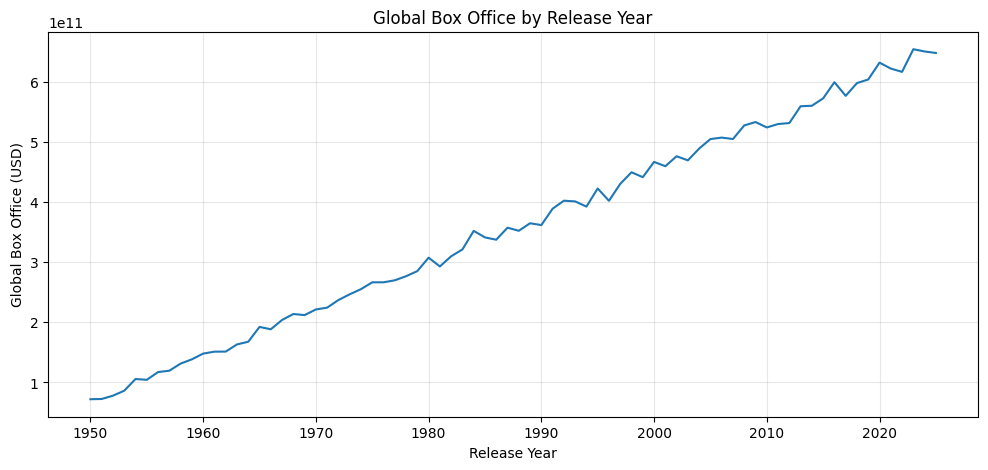

In [22]:
annual_summary = (
    df.groupby(
        "ReleaseYear",
        observed=True
    )
    .agg(
        Movies=(
            "MovieID",
            "nunique"
        ),
        TotalBudgetUSD=(
            "BudgetUSD",
            "sum"
        ),
        TotalUSBoxOfficeUSD=(
            "US_BoxOfficeUSD",
            "sum"
        ),
        TotalGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "sum"
        ),
        TotalProfitUSD=(
            "ProfitUSD",
            "sum"
        ),
        AverageIMDbRating=(
            "IMDbRating",
            "mean"
        ),
        SuccessRate=(
            "IsProfitable",
            "mean"
        ),
    )
    .reset_index()
    .sort_values("ReleaseYear")
)

annual_summary["PortfolioROI"] = (
    annual_summary["TotalProfitUSD"]
    / annual_summary["TotalBudgetUSD"]
)

display(annual_summary.tail(10))

fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    annual_summary["ReleaseYear"],
    annual_summary[
        "TotalGlobalBoxOfficeUSD"
    ]
)

ax.set_title(
    "Global Box Office by Release Year"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Global Box Office (USD)")
ax.grid(alpha=0.3)

plt.show()

,Genre,Movies,TotalBudgetUSD,TotalGlobalBoxOfficeUSD,TotalProfitUSD,AverageIMDbRating,AverageRTScore,TotalIMDbVotes,SuccessRate,PortfolioROI
3,Drama,250018,"2,448,711,908,669.550","6,788,589,758,758.330","4,339,877,850,088.780",6.487,64.718,2287961311,0.889,1.772
1,Comedy,199832,"1,963,653,586,320.640","5,439,413,114,727.420","3,475,759,528,406.780",6.499,64.801,1836722691,0.889,1.770
0,Action,150131,"1,443,620,882,404.170","4,030,095,779,474.210","2,586,474,897,070.040",6.496,64.807,1370146034,0.890,1.792
4,Horror,100010,"988,041,469,437.720","2,748,348,306,425.940","1,760,306,836,988.220",6.500,64.847,919991252,0.890,1.782
7,Thriller,100071,"989,455,500,798.790","2,745,383,120,770.950","1,755,927,619,972.160",6.495,64.790,904733906,0.889,1.775
5,Romance,100021,"984,627,160,912.440","2,728,887,424,760.390","1,744,260,263,847.950",6.492,64.782,908021119,0.890,1.771
2,Documentary,50114,"497,687,365,661.090","1,382,233,107,288.920","884,545,741,627.830",6.501,64.748,458573264,0.888,1.777
6,Sci-Fi,49802,"487,015,874,159.440","1,343,275,863,715.200","856,259,989,555.760",6.499,64.725,451025297,0.890,1.758


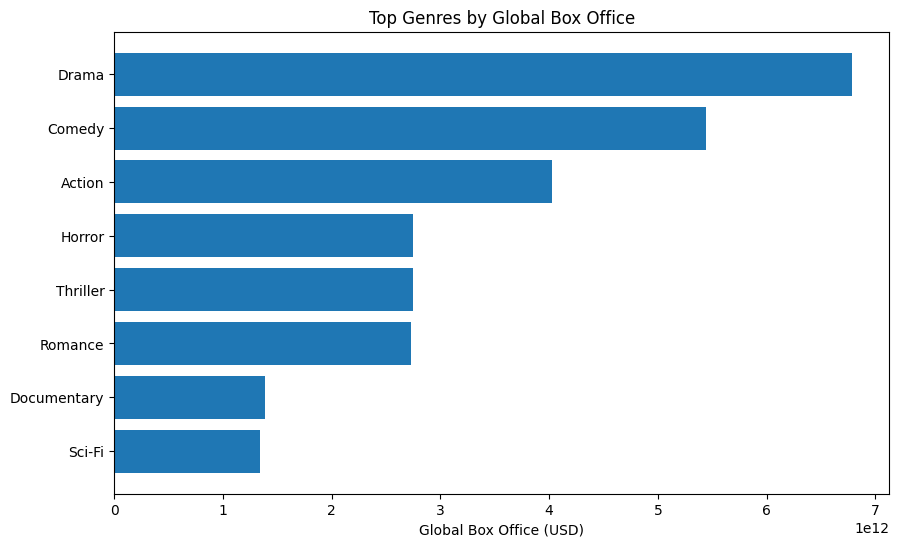

In [23]:
genre_summary = (
    df.groupby(
        "Genre",
        observed=True
    )
    .agg(
        Movies=(
            "MovieID",
            "nunique"
        ),
        TotalBudgetUSD=(
            "BudgetUSD",
            "sum"
        ),
        TotalGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "sum"
        ),
        TotalProfitUSD=(
            "ProfitUSD",
            "sum"
        ),
        AverageIMDbRating=(
            "IMDbRating",
            "mean"
        ),
        AverageRTScore=(
            "RottenTomatoesScore",
            "mean"
        ),
        TotalIMDbVotes=(
            "NumVotesIMDb",
            "sum"
        ),
        SuccessRate=(
            "IsProfitable",
            "mean"
        ),
    )
    .reset_index()
)

genre_summary["PortfolioROI"] = (
    genre_summary["TotalProfitUSD"]
    / genre_summary["TotalBudgetUSD"]
)

genre_summary = genre_summary.sort_values(
    "TotalGlobalBoxOfficeUSD",
    ascending=False
)

display(genre_summary.head(15))

plot_data = (
    genre_summary
    .head(12)
    .sort_values(
        "TotalGlobalBoxOfficeUSD"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    plot_data["Genre"].astype(str),
    plot_data[
        "TotalGlobalBoxOfficeUSD"
    ]
)

ax.set_title(
    "Top Genres by Global Box Office"
)

ax.set_xlabel(
    "Global Box Office (USD)"
)

plt.show()

In [24]:
country_summary = (
    df.groupby(
        "Country",
        observed=True
    )
    .agg(
        Movies=(
            "MovieID",
            "nunique"
        ),
        TotalBudgetUSD=(
            "BudgetUSD",
            "sum"
        ),
        TotalUSBoxOfficeUSD=(
            "US_BoxOfficeUSD",
            "sum"
        ),
        TotalInternationalBoxOfficeUSD=(
            "International_BoxOfficeUSD",
            "sum"
        ),
        TotalGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "sum"
        ),
        TotalProfitUSD=(
            "ProfitUSD",
            "sum"
        ),
        AverageIMDbRating=(
            "IMDbRating",
            "mean"
        ),
        SuccessRate=(
            "IsProfitable",
            "mean"
        ),
    )
    .reset_index()
)

country_summary["PortfolioROI"] = (
    country_summary["TotalProfitUSD"]
    / country_summary["TotalBudgetUSD"]
)

country_summary = (
    country_summary
    .sort_values(
        "TotalGlobalBoxOfficeUSD",
        ascending=False
    )
)

display(country_summary.head(15))

,Country,Movies,TotalBudgetUSD,TotalUSBoxOfficeUSD,TotalInternationalBoxOfficeUSD,TotalGlobalBoxOfficeUSD,TotalProfitUSD,AverageIMDbRating,SuccessRate,PortfolioROI
9,USA,714581,"6,991,153,965,966.140","10,684,175,631,791.949","8,741,414,649,413.650","19,425,590,281,205.602","12,434,436,315,239.461",6.496,0.889,1.779
8,UK,51277,"515,185,326,355.490","781,187,687,255.130","643,416,840,171.390","1,424,604,527,426.520","909,419,201,071.030",6.496,0.889,1.765
5,India,50984,"503,525,565,059.100","765,346,586,484.970","628,949,777,137.060","1,394,296,363,622.030","890,770,798,562.930",6.494,0.891,1.769
1,Canada,40528,"398,994,691,771.390","608,206,495,239.220","498,396,919,542.930","1,106,603,414,782.150","707,608,723,010.760",6.480,0.887,1.773
2,China,30952,"299,799,348,072.820","457,426,635,615.410","372,721,726,604.840","830,148,362,220.250","530,349,014,147.430",6.497,0.887,1.769
0,Australia,30587,"300,861,226,963.180","457,217,301,600.410","370,513,522,062.440","827,730,823,662.850","526,869,596,699.670",6.500,0.891,1.751
3,France,30471,"297,703,992,364.110","453,243,692,874.810","372,074,669,768.090","825,318,362,642.900","527,614,370,278.790",6.489,0.891,1.772
4,Germany,20211,"199,661,291,763.160","303,385,761,287.920","247,356,860,979.510","550,742,622,267.430","351,081,330,504.270",6.476,0.888,1.758
6,Japan,20222,"196,071,981,549.990","298,945,864,150.260","244,212,845,176.120","543,158,709,326.380","347,086,727,776.390",6.506,0.887,1.770
7,South Korea,10186,"99,856,358,498.460","152,481,361,086.380","125,551,647,678.870","278,033,008,765.250","178,176,650,266.790",6.482,0.892,1.784


,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,ProfitUSD,ROI
BudgetUSD,1.000,0.883,0.895,0.789,-0.001
US_BoxOfficeUSD,0.883,1.000,0.986,0.966,0.174
Global_BoxOfficeUSD,0.895,0.986,1.000,0.980,0.176
ProfitUSD,0.789,0.966,0.980,1.000,0.244
ROI,-0.001,0.174,0.176,0.244,1.000


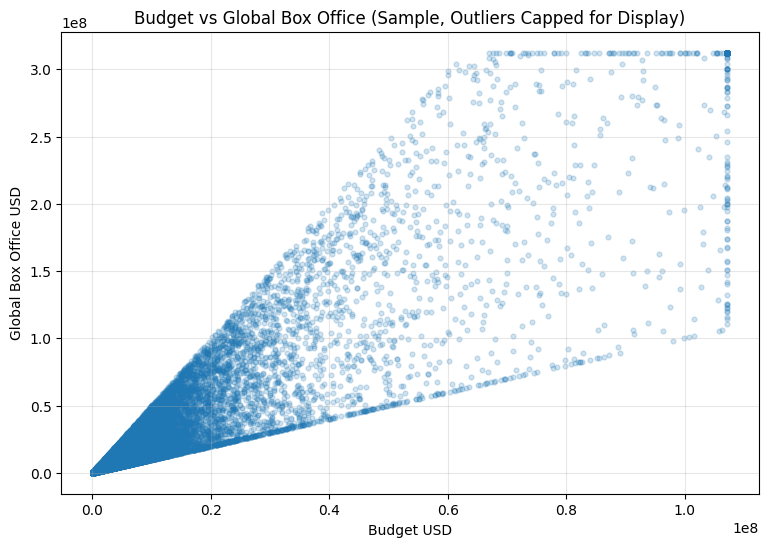

In [25]:
financial_correlation = df[
    [
        "BudgetUSD",
        "US_BoxOfficeUSD",
        "Global_BoxOfficeUSD",
        "ProfitUSD",
        "ROI",
    ]
].corr(numeric_only=True)

display(financial_correlation)

sample_size = min(
    25_000,
    len(df)
)

scatter_sample = df.sample(
    sample_size,
    random_state=42
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    scatter_sample["BudgetUSD_Visual"],
    scatter_sample[
        "Global_BoxOfficeUSD_Visual"
    ],
    alpha=0.2,
    s=12
)

ax.set_title(
    "Budget vs Global Box Office "
    "(Sample, Outliers Capped for Display)"
)

ax.set_xlabel("Budget USD")
ax.set_ylabel("Global Box Office USD")
ax.grid(alpha=0.3)

plt.show()

,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Global_BoxOfficeUSD,ProfitUSD
IMDbRating,1.000,0.829,-0.001,-0.001,0.001,0.001
RottenTomatoesScore,0.829,1.000,-0.002,-0.002,0.001,0.001
NumVotesIMDb,-0.001,-0.002,1.000,-0.000,0.000,0.000
NumVotesRT,-0.001,-0.002,-0.000,1.000,0.002,0.002
Global_BoxOfficeUSD,0.001,0.001,0.000,0.002,1.000,0.980
ProfitUSD,0.001,0.001,0.000,0.002,0.980,1.000


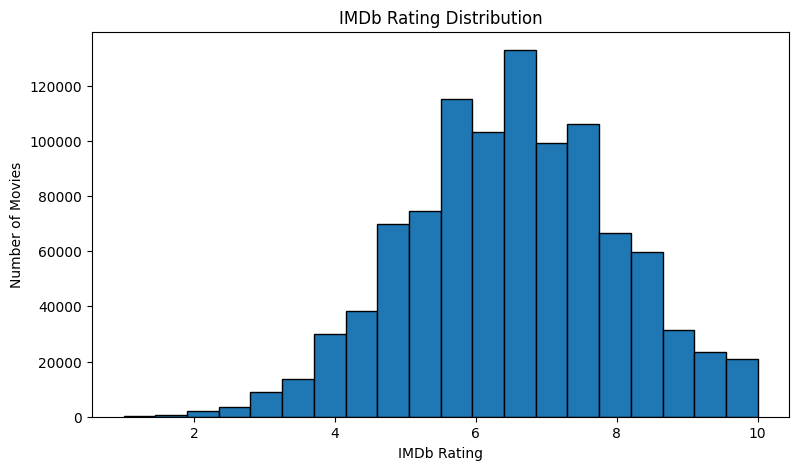

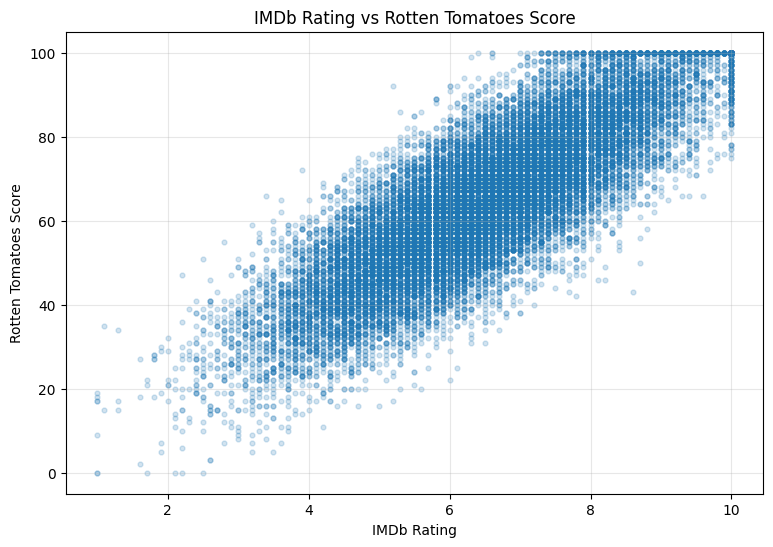

In [26]:

rating_correlation = df[
    [
        "IMDbRating",
        "RottenTomatoesScore",
        "NumVotesIMDb",
        "NumVotesRT",
        "Global_BoxOfficeUSD",
        "ProfitUSD",
    ]
].corr(numeric_only=True)

display(rating_correlation)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.hist(
    df["IMDbRating"].dropna(),
    bins=20,
    edgecolor="black"
)

ax.set_title(
    "IMDb Rating Distribution"
)

ax.set_xlabel("IMDb Rating")
ax.set_ylabel("Number of Movies")

plt.show()

rating_sample = df.sample(
    min(25_000, len(df)),
    random_state=42
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    rating_sample["IMDbRating"],
    rating_sample[
        "RottenTomatoesScore"
    ],
    alpha=0.2,
    s=12
)

ax.set_title(
    "IMDb Rating vs "
    "Rotten Tomatoes Score"
)

ax.set_xlabel("IMDb Rating")

ax.set_ylabel(
    "Rotten Tomatoes Score"
)

ax.grid(alpha=0.3)

plt.show()

,ReleaseMonthNo,ReleaseMonth,Movies,TotalGlobalBoxOfficeUSD,AverageGlobalBoxOfficeUSD,TotalProfitUSD,AverageIMDbRating,SuccessRate
0,1,January,84693,"2,285,283,309,450.880","26,983,142.756","1,464,745,397,004.780",6.495,0.890
1,2,February,77490,"2,094,909,797,506.520","27,034,582.495","1,339,669,617,840.020",6.496,0.889
2,3,March,84811,"2,309,740,789,122.890","27,233,976.596","1,476,276,164,830.780",6.497,0.890
3,4,April,81744,"2,215,470,315,054.970","27,102,543.490","1,417,522,823,439.480",6.492,0.888
4,5,May,85164,"2,314,180,197,960.310","27,173,221.055","1,484,352,142,214.820",6.485,0.889
5,6,June,82462,"2,259,893,244,241.650","27,405,268.417","1,444,996,839,032.390",6.492,0.889
6,7,July,85311,"2,343,673,698,717.520","27,472,116.125","1,493,658,085,439.130",6.498,0.889
7,8,August,84690,"2,260,562,642,794.530","26,692,202.654","1,443,941,661,839.890",6.493,0.891
8,9,September,82114,"2,256,993,161,654.200","27,486,094.474","1,448,199,690,984.770",6.495,0.888
9,10,October,85360,"2,318,297,978,772.730","27,159,067.230","1,480,569,504,967.680",6.508,0.889


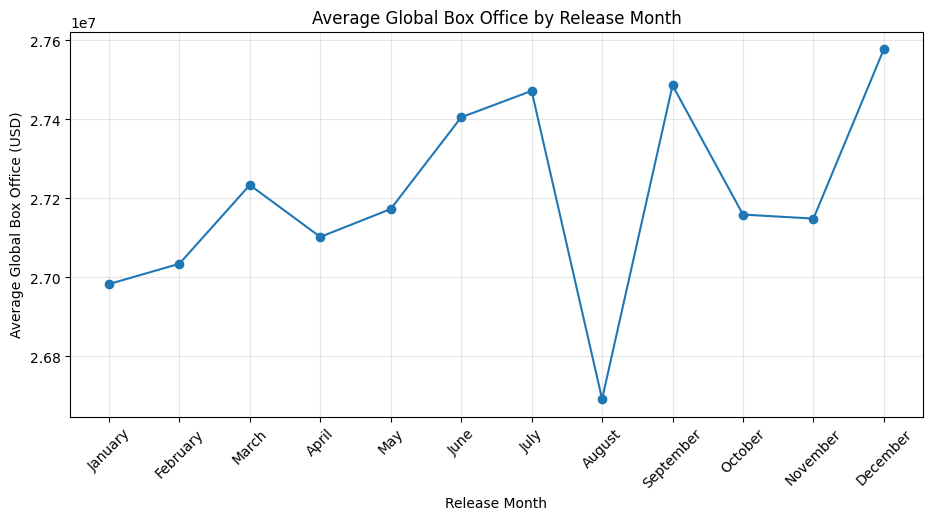

In [27]:
month_summary = (
    df.groupby(
        [
            "ReleaseMonthNo",
            "ReleaseMonth"
        ],
        observed=True
    )
    .agg(
        Movies=(
            "MovieID",
            "nunique"
        ),
        TotalGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "sum"
        ),
        AverageGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "mean"
        ),
        TotalProfitUSD=(
            "ProfitUSD",
            "sum"
        ),
        AverageIMDbRating=(
            "IMDbRating",
            "mean"
        ),
        SuccessRate=(
            "IsProfitable",
            "mean"
        ),
    )
    .reset_index()
    .sort_values("ReleaseMonthNo")
)

display(month_summary)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    month_summary[
        "ReleaseMonth"
    ].astype(str),
    month_summary[
        "AverageGlobalBoxOfficeUSD"
    ],
    marker="o"
)

ax.set_title(
    "Average Global Box Office "
    "by Release Month"
)

ax.set_xlabel("Release Month")

ax.set_ylabel(
    "Average Global Box Office (USD)"
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(alpha=0.3)

plt.show()

In [28]:
MIN_MOVIES_DIRECTOR = 20
MIN_MOVIES_ACTOR = 20

director_summary = (
    df.groupby(
        "Director",
        observed=True
    )
    .agg(
        Movies=(
            "MovieID",
            "nunique"
        ),
        TotalBudgetUSD=(
            "BudgetUSD",
            "sum"
        ),
        TotalGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "sum"
        ),
        TotalProfitUSD=(
            "ProfitUSD",
            "sum"
        ),
        AverageIMDbRating=(
            "IMDbRating",
            "mean"
        ),
        AverageRTScore=(
            "RottenTomatoesScore",
            "mean"
        ),
        TotalIMDbVotes=(
            "NumVotesIMDb",
            "sum"
        ),
        SuccessRate=(
            "IsProfitable",
            "mean"
        ),
    )
    .reset_index()
)

director_summary["PortfolioROI"] = (
    director_summary["TotalProfitUSD"]
    / director_summary["TotalBudgetUSD"]
)

qualified_directors = (
    director_summary[
        director_summary["Movies"]
        >= MIN_MOVIES_DIRECTOR
    ]
    .sort_values(
        [
            "TotalProfitUSD",
            "AverageIMDbRating"
        ],
        ascending=[
            False,
            False
        ]
    )
)

actor_summary = (
    df.groupby(
        "LeadActor",
        observed=True
    )
    .agg(
        Movies=(
            "MovieID",
            "nunique"
        ),
        TotalBudgetUSD=(
            "BudgetUSD",
            "sum"
        ),
        TotalGlobalBoxOfficeUSD=(
            "Global_BoxOfficeUSD",
            "sum"
        ),
        TotalProfitUSD=(
            "ProfitUSD",
            "sum"
        ),
        AverageIMDbRating=(
            "IMDbRating",
            "mean"
        ),
        AverageRTScore=(
            "RottenTomatoesScore",
            "mean"
        ),
        TotalIMDbVotes=(
            "NumVotesIMDb",
            "sum"
        ),
        SuccessRate=(
            "IsProfitable",
            "mean"
        ),
    )
    .reset_index()
)

actor_summary["PortfolioROI"] = (
    actor_summary["TotalProfitUSD"]
    / actor_summary["TotalBudgetUSD"]
)

qualified_actors = (
    actor_summary[
        actor_summary["Movies"]
        >= MIN_MOVIES_ACTOR
    ]
    .sort_values(
        [
            "TotalProfitUSD",
            "AverageIMDbRating"
        ],
        ascending=[
            False,
            False
        ]
    )
)

display(
    qualified_directors.head(15)
)

display(
    qualified_actors.head(15)
)

,Director,Movies,TotalBudgetUSD,TotalGlobalBoxOfficeUSD,TotalProfitUSD,AverageIMDbRating,AverageRTScore,TotalIMDbVotes,SuccessRate,PortfolioROI
82,Judy Walker,6658,"69,055,475,376.990","194,740,416,291.050","125,684,940,914.060",6.461,64.391,60686452,0.888,1.820
3,Albert Phillips,6634,"69,325,915,472.560","194,476,114,920.580","125,150,199,448.020",6.482,64.789,58933156,0.899,1.805
19,Brooke Morales,6750,"67,206,427,298.920","191,935,444,167.680","124,729,016,868.760",6.488,64.786,61953883,0.888,1.856
51,Emily Miller,6776,"68,403,647,104.900","193,126,366,895.100","124,722,719,790.200",6.521,64.996,61397663,0.891,1.823
149,William Walker,6758,"68,390,803,239.360","192,378,455,764.990","123,987,652,525.630",6.498,64.716,63048102,0.892,1.813
77,Jonathan Evans,6712,"67,411,952,247.090","191,099,774,359.390","123,687,822,112.300",6.500,64.711,65402659,0.897,1.835
45,Diane Skinner,6675,"68,091,355,660.510","191,766,030,262.970","123,674,674,602.460",6.513,64.823,59950253,0.892,1.816
134,Sharon Wilson,6673,"67,939,700,832.600","191,278,789,719.350","123,339,088,886.750",6.489,64.701,56761046,0.884,1.815
90,Kim Watkins,6657,"67,288,836,492.030","190,566,781,725.130","123,277,945,233.100",6.456,64.543,59157881,0.892,1.832
133,Shannon Ross,6489,"66,924,719,889.980","190,039,518,152.730","123,114,798,262.750",6.504,64.988,56349337,0.891,1.840


,LeadActor,Movies,TotalBudgetUSD,TotalGlobalBoxOfficeUSD,TotalProfitUSD,AverageIMDbRating,AverageRTScore,TotalIMDbVotes,SuccessRate,PortfolioROI
125,Jeffrey Smith,6688,"65,979,293,544.750","185,012,786,239.820","119,033,492,695.070",6.513,65.089,59844934,0.890,1.804
101,Eric Obrien,3313,"36,634,219,215.290","105,515,870,210.460","68,881,650,995.170",6.473,64.426,29229592,0.892,1.880
214,Nathan Nelson,3485,"37,794,472,976.080","104,230,906,756.270","66,436,433,780.190",6.494,64.639,33440670,0.890,1.758
173,Lawrence Thomas,3412,"34,857,802,782.500","100,363,541,389.220","65,505,738,606.720",6.481,64.722,31978070,0.891,1.879
264,Sheila Dunn,3391,"36,377,504,632.710","101,802,836,807.850","65,425,332,175.140",6.529,64.905,31045115,0.886,1.799
128,Jennifer Hendricks,3338,"35,326,759,711.210","100,476,945,903.770","65,150,186,192.560",6.459,64.742,34568253,0.893,1.844
167,Kristy Faulkner,3293,"35,702,807,763.050","100,111,595,203.330","64,408,787,440.280",6.447,64.359,28056973,0.890,1.804
243,Russell Martin,3370,"36,100,743,737.960","100,235,810,207.520","64,135,066,469.560",6.490,64.623,32863296,0.880,1.777
44,Carl Schneider,3310,"34,051,674,057.140","97,925,064,249.160","63,873,390,192.020",6.496,64.580,27846881,0.889,1.876
139,John Perry,3397,"35,881,461,184.040","99,275,709,824.680","63,394,248,640.640",6.484,64.569,31314062,0.887,1.767


In [29]:
top_movies = df[
    [
        "MovieID",
        "Title",
        "Genre",
        "ReleaseYear",
        "Country",
        "Director",
        "LeadActor",
        "BudgetUSD",
        "US_BoxOfficeUSD",
        "International_BoxOfficeUSD",
        "Global_BoxOfficeUSD",
        "ProfitUSD",
        "ROI",
        "IMDbRating",
        "RottenTomatoesScore",
        "NumVotesIMDb",
        "SuccessTier",
    ]
].sort_values(
    [
        "Global_BoxOfficeUSD",
        "ProfitUSD"
    ],
    ascending=[
        False,
        False
    ]
)

display(top_movies.head(20))

,MovieID,Title,Genre,ReleaseYear,Country,Director,LeadActor,BudgetUSD,US_BoxOfficeUSD,International_BoxOfficeUSD,Global_BoxOfficeUSD,ProfitUSD,ROI,IMDbRating,RottenTomatoesScore,NumVotesIMDb,SuccessTier
220370,220371,Scientist picture,Documentary,1977,USA,Joshua Baker,Ashley Reeves,"300,000,000.000","784,819,473.500","714,677,246.500","1,499,496,720.000","1,199,496,720.000",3.998,5.400,69.000,244,Profitable
334338,334339,Among religious night,Comedy,2013,USA,Paul Rogers,George Green,"300,000,000.000","688,602,564.100","810,865,253.900","1,499,467,818.000","1,199,467,818.000",3.998,7.300,73.000,11072,Blockbuster
788782,788783,Happy religious serious citizen,Sci-Fi,2003,USA,Anthony Rowland,Brian Rodriguez,"300,000,000.000","742,962,955.700","753,227,377.300","1,496,190,333.000","1,196,190,333.000",3.987,6.500,58.000,2546,Hit
970554,970555,Free cup day tree,Drama,1951,USA,Claudia Smith,Duane Fletcher DDS,"300,000,000.000","989,194,085.000","506,622,400.000","1,495,816,485.000","1,195,816,485.000",3.986,8.300,93.000,3959,Blockbuster
504069,504070,Cut,Drama,2000,USA,Samantha Campbell,Tricia Thomas,"300,000,000.000","792,936,970.500","702,255,306.500","1,495,192,277.000","1,195,192,277.000",3.984,3.800,32.000,989,Profitable
10947,10948,Seem fish send people,Comedy,2009,USA,Tyler Sanchez,Jennifer Hendricks,"300,000,000.000","641,619,672.400","853,187,729.600","1,494,807,402.000","1,194,807,402.000",3.983,2.700,32.000,324,Profitable
34110,34111,Production five rule,Thriller,2003,USA,Abigail Robles,John Perry,"300,000,000.000","967,863,965.400","525,707,905.600","1,493,571,871.000","1,193,571,871.000",3.979,8.300,89.000,21106,Blockbuster
924737,924738,Which team deep,Comedy,2024,Canada,Gary Simmons,William Ramirez,"300,000,000.000","848,957,782.100","643,701,961.900","1,492,659,744.000","1,192,659,744.000",3.976,6.600,84.000,8148,Hit
932597,932598,Serve view,Drama,1984,USA,Diane Skinner,Becky Kerr,"300,000,000.000","836,899,520.700","652,786,378.300","1,489,685,899.000","1,189,685,899.000",3.966,8.500,89.000,100,Blockbuster
194388,194389,Take exist good,Comedy,2020,USA,Robert Hendricks,William Brooks,"300,000,000.000","898,835,893.300","589,027,992.700","1,487,863,886.000","1,187,863,886.000",3.960,10.000,100.000,7197,Blockbuster


In [30]:
def build_dimension(
    dataframe,
    source_column,
    key_column,
    name_column
):
    dimension = (
        dataframe[[source_column]]
        .drop_duplicates()
        .dropna()
        .sort_values(source_column)
        .reset_index(drop=True)
        .rename(
            columns={
                source_column: name_column
            }
        )
    )

    dimension.insert(
        0,
        key_column,
        np.arange(
            1,
            len(dimension) + 1
        )
    )

    return dimension


dim_genre = build_dimension(
    df,
    "Genre",
    "GenreKey",
    "Genre"
)

dim_country = build_dimension(
    df,
    "Country",
    "CountryKey",
    "Country"
)

dim_director = build_dimension(
    df,
    "Director",
    "DirectorKey",
    "Director"
)

dim_actor = build_dimension(
    df,
    "LeadActor",
    "ActorKey",
    "LeadActor"
)

display(dim_genre.head())
display(dim_country.head())
display(dim_director.head())
display(dim_actor.head())

,GenreKey,Genre
0,1,Action
1,2,Comedy
2,3,Documentary
3,4,Drama
4,5,Horror


,CountryKey,Country
0,1,Australia
1,2,Canada
2,3,China
3,4,France
4,5,Germany


,DirectorKey,Director
0,1,Abigail Robles
1,2,Adam Brown
2,3,Adriana Campbell
3,4,Albert Phillips
4,5,Alyssa Adams


,ActorKey,LeadActor
0,1,Adam Bowman
1,2,Adam Montes
2,3,Adam Williams
3,4,Alan Mullins
4,5,Alexander Haley


In [31]:
minimum_date = df["ReleaseDate"].min()
maximum_date = df["ReleaseDate"].max()

dim_date = pd.DataFrame({
    "Date": pd.date_range(
        minimum_date,
        maximum_date,
        freq="D"
    )
})

dim_date["DateKey"] = (
    dim_date["Date"]
    .dt.strftime("%Y%m%d")
    .astype("int32")
)

dim_date["Year"] = (
    dim_date["Date"]
    .dt.year
    .astype("int16")
)

dim_date["QuarterNo"] = (
    dim_date["Date"]
    .dt.quarter
    .astype("int8")
)

dim_date["Quarter"] = (
    "Q"
    + dim_date["QuarterNo"].astype(str)
).astype("category")

dim_date["MonthNo"] = (
    dim_date["Date"]
    .dt.month
    .astype("int8")
)

dim_date["Month"] = (
    dim_date["Date"]
    .dt.month_name()
    .astype("category")
)

dim_date["MonthShort"] = (
    dim_date["Date"]
    .dt.strftime("%b")
    .astype("category")
)

dim_date["YearMonth"] = (
    dim_date["Date"]
    .dt.strftime("%Y-%m")
)

dim_date["Day"] = (
    dim_date["Date"]
    .dt.day
    .astype("int8")
)

dim_date["DayOfWeekNo"] = (
    dim_date["Date"]
    .dt.dayofweek
    .add(1)
    .astype("int8")
)

dim_date["DayOfWeek"] = (
    dim_date["Date"]
    .dt.day_name()
    .astype("category")
)

dim_date["IsWeekend"] = (
    dim_date["DayOfWeekNo"]
    .isin([6, 7])
    .astype("int8")
)

dim_date["Decade"] = (
    (dim_date["Year"] // 10) * 10
).astype("int16")

dim_date["Season"] = (
    dim_date["MonthNo"]
    .map(month_to_season)
    .astype("category")
)

dim_date = dim_date[
    [
        "DateKey",
        "Date",
        "Year",
        "QuarterNo",
        "Quarter",
        "MonthNo",
        "Month",
        "MonthShort",
        "YearMonth",
        "Day",
        "DayOfWeekNo",
        "DayOfWeek",
        "IsWeekend",
        "Decade",
        "Season",
    ]
]

display(dim_date.head())

,DateKey,Date,Year,QuarterNo,Quarter,MonthNo,Month,MonthShort,YearMonth,Day,DayOfWeekNo,DayOfWeek,IsWeekend,Decade,Season
0,19500101,1950-01-01,1950,1,Q1,1,January,Jan,1950-01,1,7,Sunday,1,1950,Winter
1,19500102,1950-01-02,1950,1,Q1,1,January,Jan,1950-01,2,1,Monday,0,1950,Winter
2,19500103,1950-01-03,1950,1,Q1,1,January,Jan,1950-01,3,2,Tuesday,0,1950,Winter
3,19500104,1950-01-04,1950,1,Q1,1,January,Jan,1950-01,4,3,Wednesday,0,1950,Winter
4,19500105,1950-01-05,1950,1,Q1,1,January,Jan,1950-01,5,4,Thursday,0,1950,Winter


In [32]:
fact_movies = (
    df.merge(
        dim_genre,
        on="Genre",
        how="left"
    )
    .merge(
        dim_country,
        on="Country",
        how="left"
    )
    .merge(
        dim_director,
        on="Director",
        how="left"
    )
    .merge(
        dim_actor,
        on="LeadActor",
        how="left"
    )
)

fact_movies["DateKey"] = (
    fact_movies["ReleaseDate"]
    .dt.strftime("%Y%m%d")
    .astype("int32")
)

fact_columns = [
    "MovieID",
    "Title",
    "DateKey",
    "ReleaseDate",
    "ReleaseYear",
    "ReleaseMonthNo",
    "ReleaseMonth",
    "ReleaseQuarter",
    "ReleaseSeason",
    "ReleaseDayOfWeek",
    "ReleaseDecade",
    "GenreKey",
    "CountryKey",
    "DirectorKey",
    "ActorKey",
    "BudgetUSD",
    "US_BoxOfficeUSD",
    "International_BoxOfficeUSD",
    "Global_BoxOfficeUSD",
    "Opening_Day_SalesUSD",
    "One_Week_SalesUSD",
    "ProfitUSD",
    "ROI",
    "ProfitMargin",
    "OpeningDayShare",
    "FirstWeekShare",
    "IMDbRating",
    "RottenTomatoesScore",
    "NumVotesIMDb",
    "NumVotesRT",
    "BudgetBand",
    "RevenueBand",
    "IMDbRatingBand",
    "IsProfitable",
    "SuccessTier",
    "BudgetUSD_Visual",
    "Global_BoxOfficeUSD_Visual",
    "ROI_Visual",
]

fact_movies = (
    fact_movies[fact_columns]
    .copy()
)

print(
    f"Fact rows: "
    f"{len(fact_movies):,}"
)

print(
    f"Fact columns: "
    f"{fact_movies.shape[1]}"
)

display(fact_movies.head())

Fact rows: 999,999
Fact columns: 38


,MovieID,Title,DateKey,ReleaseDate,ReleaseYear,ReleaseMonthNo,ReleaseMonth,ReleaseQuarter,ReleaseSeason,ReleaseDayOfWeek,ReleaseDecade,GenreKey,CountryKey,DirectorKey,ActorKey,BudgetUSD,US_BoxOfficeUSD,International_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,ProfitUSD,ROI,ProfitMargin,OpeningDayShare,FirstWeekShare,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,BudgetBand,RevenueBand,IMDbRatingBand,IsProfitable,SuccessTier,BudgetUSD_Visual,Global_BoxOfficeUSD_Visual,ROI_Visual
0,1,Might toward capital,20030928,2003-09-28,2003,9,September,Q3,Fall,Sunday,2000,2,3,93,39,"6,577,427.790","6,613,685.820","8,858,349.840","15,472,035.660","1,778,530.850","3,034,053.320","8,894,607.870",1.352,0.575,0.115,0.196,6.200,58.000,7865,10596,Under $10M,Under $25M,6-6.9,1,Profitable,"6,577,427.790","15,472,035.660",1.352
1,2,He however experience,19880214,1988-02-14,1988,2,February,Q1,Winter,Sunday,1980,2,10,14,25,"1,883,810.100","1,930,949.150","1,706,781.970","3,637,731.120","247,115.740","831,828.840","1,753,921.020",0.931,0.482,0.068,0.229,5.200,44.000,1708,220,Under $10M,Under $25M,5-5.9,1,Profitable,"1,883,810.100","3,637,731.120",0.931
2,3,Star responsibility politics,19711102,1971-11-02,1971,11,November,Q4,Fall,Tuesday,1970,2,10,88,5,"2,468,079.290","4,186,694.690","2,978,416.550","7,165,111.240","878,453.950","2,171,405.930","4,697,031.950",1.903,0.656,0.123,0.303,5.500,55.000,4678,7805,Under $10M,Under $25M,5-5.9,1,Profitable,"2,468,079.290","7,165,111.240",1.903
3,4,Exactly live,19980806,1998-08-06,1998,8,August,Q3,Summer,Thursday,1990,2,10,109,229,"1,447,311.460","2,023,683.920","2,350,136.340","4,373,820.260","570,657.720","898,886.010","2,926,508.800",2.022,0.669,0.130,0.206,7.300,87.000,2467,1751,Under $10M,Under $25M,7-7.9,1,Hit,"1,447,311.460","4,373,820.260",2.022
4,5,Focus improve especially,20211217,2021-12-17,2021,12,December,Q4,Winter,Friday,2020,3,6,54,96,"900,915.860","2,129,629.100","983,388.280","3,113,017.380","361,189.370","861,775.910","2,212,101.520",2.455,0.711,0.116,0.277,6.100,67.000,5555,697,Under $10M,Under $25M,6-6.9,1,Profitable,"900,915.860","3,113,017.380",2.455


In [33]:
model_tables = {
    "FactMovies": fact_movies,
    "DimDate": dim_date,
    "DimGenre": dim_genre,
    "DimCountry": dim_country,
    "DimDirector": dim_director,
    "DimActor": dim_actor,
}

parquet_available = True

try:
    import pyarrow

except ImportError:
    parquet_available = False

    print(
        "PyArrow is unavailable. "
        "CSV files will still be exported."
    )

for table_name, table in model_tables.items():
    csv_file = (
        EXPORT_DIR
        / f"{table_name}.csv"
    )

    table.to_csv(
        csv_file,
        index=False
    )

    export_message = (
        f"Exported {table_name} CSV: "
        f"{len(table):,} rows, "
        f"{table.shape[1]} columns"
    )

    if parquet_available:
        parquet_file = (
            EXPORT_DIR
            / f"{table_name}.parquet"
        )

        table.to_parquet(
            parquet_file,
            index=False,
            compression="snappy"
        )

        export_message += " + Parquet"

    print(export_message)

Exported FactMovies CSV: 999,999 rows, 38 columns + Parquet
Exported DimDate CSV: 27,759 rows, 15 columns + Parquet
Exported DimGenre CSV: 8 rows, 2 columns + Parquet
Exported DimCountry CSV: 10 rows, 2 columns + Parquet
Exported DimDirector CSV: 150 rows, 2 columns + Parquet
Exported DimActor CSV: 299 rows, 2 columns + Parquet


In [34]:
summary_tables = {
    "AnnualSummary": annual_summary,
    "GenreSummary": genre_summary,
    "CountrySummary": country_summary,
    "MonthSummary": month_summary,
    "DirectorSummary": director_summary,
    "QualifiedDirectors": qualified_directors,
    "ActorSummary": actor_summary,
    "QualifiedActors": qualified_actors,
    "TopMovies": top_movies.head(500),
    "KPISummary": kpi_summary,
}

for table_name, table in summary_tables.items():
    table.to_csv(
        EXPORT_DIR / f"{table_name}.csv",
        index=False
    )

print("Summary tables exported.")

Summary tables exported.


In [35]:
data_dictionary = pd.DataFrame(
    [
        [
            "MovieID",
            "FactMovies",
            "Unique movie identifier",
            "Whole number"
        ],
        [
            "Title",
            "FactMovies",
            "Movie title",
            "Text"
        ],
        [
            "DateKey",
            "FactMovies",
            "Foreign key to DimDate",
            "Whole number"
        ],
        [
            "GenreKey",
            "FactMovies",
            "Foreign key to DimGenre",
            "Whole number"
        ],
        [
            "CountryKey",
            "FactMovies",
            "Foreign key to DimCountry",
            "Whole number"
        ],
        [
            "DirectorKey",
            "FactMovies",
            "Foreign key to DimDirector",
            "Whole number"
        ],
        [
            "ActorKey",
            "FactMovies",
            "Foreign key to DimActor",
            "Whole number"
        ],
        [
            "BudgetUSD",
            "FactMovies",
            "Production budget in USD",
            "Decimal number"
        ],
        [
            "US_BoxOfficeUSD",
            "FactMovies",
            "US box-office revenue in USD",
            "Decimal number"
        ],
        [
            "International_BoxOfficeUSD",
            "FactMovies",
            "Global revenue minus US revenue",
            "Decimal number"
        ],
        [
            "Global_BoxOfficeUSD",
            "FactMovies",
            "Worldwide box-office revenue in USD",
            "Decimal number"
        ],
        [
            "ProfitUSD",
            "FactMovies",
            "Global box office minus budget",
            "Decimal number"
        ],
        [
            "ROI",
            "FactMovies",
            "Profit divided by budget",
            "Decimal number"
        ],
        [
            "ProfitMargin",
            "FactMovies",
            "Profit divided by global revenue",
            "Decimal number"
        ],
        [
            "OpeningDayShare",
            "FactMovies",
            "Opening-day sales divided by global revenue",
            "Decimal number"
        ],
        [
            "FirstWeekShare",
            "FactMovies",
            "First-week sales divided by global revenue",
            "Decimal number"
        ],
        [
            "IMDbRating",
            "FactMovies",
            "IMDb audience rating from 0 to 10",
            "Decimal number"
        ],
        [
            "RottenTomatoesScore",
            "FactMovies",
            "Rotten Tomatoes score from 0 to 100",
            "Decimal number"
        ],
        [
            "NumVotesIMDb",
            "FactMovies",
            "Number of IMDb votes",
            "Whole number"
        ],
        [
            "NumVotesRT",
            "FactMovies",
            "Number of Rotten Tomatoes votes",
            "Whole number"
        ],
        [
            "IsProfitable",
            "FactMovies",
            "1 when profit is positive, otherwise 0",
            "Whole number"
        ],
        [
            "SuccessTier",
            "FactMovies",
            "Blockbuster, Hit, Profitable, or Underperformer",
            "Text"
        ],
        [
            "Date",
            "DimDate",
            "Calendar date used for time intelligence",
            "Date"
        ],
        [
            "Genre",
            "DimGenre",
            "Movie genre",
            "Text"
        ],
        [
            "Country",
            "DimCountry",
            "Production country",
            "Text"
        ],
        [
            "Director",
            "DimDirector",
            "Movie director",
            "Text"
        ],
        [
            "LeadActor",
            "DimActor",
            "Lead actor",
            "Text"
        ],
    ],
    columns=[
        "Column",
        "Table",
        "Description",
        "RecommendedPowerBIType"
    ]
)

display(data_dictionary)

data_dictionary.to_csv(
    REPORT_DIR / "data_dictionary.csv",
    index=False
)

,Column,Table,Description,RecommendedPowerBIType
0,MovieID,FactMovies,Unique movie identifier,Whole number
1,Title,FactMovies,Movie title,Text
2,DateKey,FactMovies,Foreign key to DimDate,Whole number
3,GenreKey,FactMovies,Foreign key to DimGenre,Whole number
4,CountryKey,FactMovies,Foreign key to DimCountry,Whole number
5,DirectorKey,FactMovies,Foreign key to DimDirector,Whole number
6,ActorKey,FactMovies,Foreign key to DimActor,Whole number
7,BudgetUSD,FactMovies,Production budget in USD,Decimal number
8,US_BoxOfficeUSD,FactMovies,US box-office revenue in USD,Decimal number
9,International_BoxOfficeUSD,FactMovies,Global revenue minus US revenue,Decimal number


In [36]:
best_genre_revenue = (
    genre_summary.iloc[0]
)

best_country_revenue = (
    country_summary.iloc[0]
)

best_year_revenue = annual_summary.loc[
    annual_summary[
        "TotalGlobalBoxOfficeUSD"
    ].idxmax()
]

best_month_average = month_summary.loc[
    month_summary[
        "AverageGlobalBoxOfficeUSD"
    ].idxmax()
]

highest_profit_movie = (
    top_movies
    .sort_values(
        "ProfitUSD",
        ascending=False
    )
    .iloc[0]
)

budget_revenue_corr = (
    df["BudgetUSD"]
    .corr(
        df["Global_BoxOfficeUSD"]
    )
)

imdb_rt_corr = (
    df["IMDbRating"]
    .corr(
        df["RottenTomatoesScore"]
    )
)

imdb_revenue_corr = (
    df["IMDbRating"]
    .corr(
        df["Global_BoxOfficeUSD"]
    )
)

story_lines = [
    (
        "FILM INDUSTRY ANALYTICS - "
        "AUTOMATIC STORYTELLING SUMMARY"
    ),
    "",
    (
        f"1. The cleaned model contains "
        f"{df['MovieID'].nunique():,} "
        f"unique movies."
    ),
    (
        f"2. Total global box office equals "
        f"${total_global_revenue:,.0f}, "
        f"compared with a total production "
        f"budget of ${total_budget:,.0f}."
    ),
    (
        f"3. The portfolio generated "
        f"${total_profit:,.0f} in total profit, "
        f"with an overall ROI of "
        f"{safe_ratio(total_profit, total_budget):.2%}."
    ),
    (
        f"4. {profitable_movies:,} movies "
        f"were profitable, producing a "
        f"success rate of "
        f"{safe_ratio(profitable_movies, df['MovieID'].nunique()):.2%}."
    ),
    (
        f"5. {best_genre_revenue['Genre']} "
        f"generated the highest total global "
        f"box office among genres."
    ),
    (
        f"6. {best_country_revenue['Country']} "
        f"generated the highest total global "
        f"box office among production countries."
    ),
    (
        f"7. "
        f"{int(best_year_revenue['ReleaseYear'])} "
        f"was the strongest year by total "
        f"global box office."
    ),
    (
        f"8. "
        f"{best_month_average['ReleaseMonth']} "
        f"had the highest average global "
        f"box office per movie."
    ),
    (
        f"9. The correlation between budget "
        f"and global box office is "
        f"{budget_revenue_corr:.3f}."
    ),
    (
        f"10. The correlation between IMDb "
        f"and Rotten Tomatoes ratings is "
        f"{imdb_rt_corr:.3f}."
    ),
    (
        f"11. The correlation between IMDb "
        f"rating and global box office is "
        f"{imdb_revenue_corr:.3f}."
    ),
    (
        f"12. The highest-profit movie is "
        f"'{highest_profit_movie['Title']}', "
        f"with profit of "
        f"${highest_profit_movie['ProfitUSD']:,.0f}."
    ),
    "",
    "RECOMMENDATIONS",
    (
        f"- Prioritize the strongest "
        f"genre-market combinations, "
        f"beginning with "
        f"{best_genre_revenue['Genre']} "
        f"and "
        f"{best_country_revenue['Country']}."
    ),
    (
        f"- Treat "
        f"{best_month_average['ReleaseMonth']} "
        f"as a candidate release window, "
        f"while validating the result "
        f"within each genre."
    ),
    (
        "- Do not evaluate budget alone; "
        "combine expected revenue, ROI, "
        "ratings, and audience-vote volume."
    ),
    (
        "- Use qualified director and actor "
        "rankings with minimum movie-count filters."
    ),
    (
        "- Separate US and international "
        "revenue when planning distribution "
        "and marketing."
    ),
]

story_text = "\n".join(story_lines)

print(story_text)

with open(
    REPORT_DIR / "storytelling_insights.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(story_text)

FILM INDUSTRY ANALYTICS - AUTOMATIC STORYTELLING SUMMARY

1. The cleaned model contains 999,999 unique movies.
2. Total global box office equals $27,206,226,475,921, compared with a total production budget of $9,802,813,748,364.
3. The portfolio generated $17,403,412,727,558 in total profit, with an overall ROI of 177.53%.
4. 889,307 movies were profitable, producing a success rate of 88.93%.
5. Drama generated the highest total global box office among genres.
6. USA generated the highest total global box office among production countries.
7. 2023 was the strongest year by total global box office.
8. December had the highest average global box office per movie.
9. The correlation between budget and global box office is 0.895.
10. The correlation between IMDb and Rotten Tomatoes ratings is 0.829.
11. The correlation between IMDb rating and global box office is 0.001.
12. The highest-profit movie is 'Scientist picture', with profit of $1,199,496,720.

RECOMMENDATIONS
- Prioritize the str

In [37]:
relationships = [
    {
        "FromTable": "FactMovies",
        "FromColumn": "DateKey",
        "ToTable": "DimDate",
        "ToColumn": "DateKey",
        "Cardinality": "Many-to-one",
        "CrossFilterDirection": "Single",
    },
    {
        "FromTable": "FactMovies",
        "FromColumn": "GenreKey",
        "ToTable": "DimGenre",
        "ToColumn": "GenreKey",
        "Cardinality": "Many-to-one",
        "CrossFilterDirection": "Single",
    },
    {
        "FromTable": "FactMovies",
        "FromColumn": "CountryKey",
        "ToTable": "DimCountry",
        "ToColumn": "CountryKey",
        "Cardinality": "Many-to-one",
        "CrossFilterDirection": "Single",
    },
    {
        "FromTable": "FactMovies",
        "FromColumn": "DirectorKey",
        "ToTable": "DimDirector",
        "ToColumn": "DirectorKey",
        "Cardinality": "Many-to-one",
        "CrossFilterDirection": "Single",
    },
    {
        "FromTable": "FactMovies",
        "FromColumn": "ActorKey",
        "ToTable": "DimActor",
        "ToColumn": "ActorKey",
        "Cardinality": "Many-to-one",
        "CrossFilterDirection": "Single",
    },
]

relationships_df = pd.DataFrame(
    relationships
)

relationships_df.to_csv(
    REPORT_DIR / "model_relationships.csv",
    index=False
)

display(relationships_df)

project_metadata = {
    "DatasetHandle": DATASET_HANDLE,
    "SourceCSV": str(CSV_PATH),
    "GeneratedTables": list(
        model_tables.keys()
    ),
    "GeneratedSummaryTables": list(
        summary_tables.keys()
    ),
    "FactRows": int(
        len(fact_movies)
    ),
    "FactColumns": int(
        fact_movies.shape[1]
    ),
}

with open(
    REPORT_DIR / "project_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        project_metadata,
        file,
        indent=2
    )

,FromTable,FromColumn,ToTable,ToColumn,Cardinality,CrossFilterDirection
0,FactMovies,DateKey,DimDate,DateKey,Many-to-one,Single
1,FactMovies,GenreKey,DimGenre,GenreKey,Many-to-one,Single
2,FactMovies,CountryKey,DimCountry,CountryKey,Many-to-one,Single
3,FactMovies,DirectorKey,DimDirector,DirectorKey,Many-to-one,Single
4,FactMovies,ActorKey,DimActor,ActorKey,Many-to-one,Single


In [38]:
zip_base = Path(
    "/content/Movie_Analytics_PowerBI_Outputs"
)

zip_file = zip_base.with_suffix(".zip")

if zip_file.exists():
    zip_file.unlink()

shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=PROJECT_DIR
)

print(f"ZIP created: {zip_file}")

print(
    f"ZIP size: "
    f"{zip_file.stat().st_size / (1024 ** 2):,.2f} MB"
)

from google.colab import files

files.download(str(zip_file))

ZIP created: /content/Movie_Analytics_PowerBI_Outputs.zip
ZIP size: 237.90 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>